In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima, ARIMA
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,root_mean_squared_error, r2_score

In [2]:
df= joblib.load(r"dataset\df.pkl")

In [3]:
df.head()

,#Passengers,month,quater,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
Month,,,,,,,,,,
1949-01-01,112,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-02-01,118,2,1,112.0,NaN,NaN,NaN,NaN,NaN,NaN
1949-03-01,132,3,1,118.0,112.0,NaN,120.666667,10.263203,NaN,NaN
1949-04-01,129,4,2,132.0,118.0,112.0,126.333333,7.371115,NaN,NaN
1949-05-01,121,5,2,129.0,132.0,118.0,127.333333,5.686241,NaN,NaN


In [4]:
df= df.asfreq('MS')

In [5]:
df.isnull().sum()

#Passengers      26
month            26
quater           26
lag1             27
lag2             28
lag3             29
rolling_mean3    28
rolling_std3     28
rolling_mean6    31
rolling_std6     31
dtype: int64

In [6]:
df.bfill(inplace=True)

In [7]:
df.duplicated().sum()

np.int64(26)

In [8]:
df.drop_duplicates(keep='first', inplace=True)

In [9]:
df.shape

(118, 10)

In [10]:
df= np.log(df)

In [11]:
df.head()

,#Passengers,month,quater,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
Month,,,,,,,,,,
1949-01-01,4.718499,0.000000,0.000000,4.718499,4.718499,4.718499,4.793032,2.328565,4.824306,2.187879
1949-02-01,4.770685,0.693147,0.000000,4.718499,4.718499,4.718499,4.793032,2.328565,4.824306,2.187879
1949-03-01,4.882802,1.098612,0.000000,4.770685,4.718499,4.718499,4.793032,2.328565,4.824306,2.187879
1949-04-01,4.859812,1.386294,0.693147,4.882802,4.770685,4.718499,4.838924,1.997569,4.824306,2.187879
1949-05-01,4.795791,1.609438,0.693147,4.859812,4.882802,4.770685,4.846808,1.738049,4.824306,2.187879


In [12]:
train= df.iloc[:-12, :].asfreq('MS')
test= df.iloc[-12:, :].asfreq('MS')

# ARIMA

Stationarity was checked explicitly in `main.ipynb` (ADF  before and after differencing)the test agreed  the raw series is non-stationary and a first difference is needed, consistent with the `d=1` that `auto_arima` selects below on its own via its internal stationarity search.

In [13]:
arima= auto_arima(
  train['#Passengers'].ffill(),
  seasonal=False
)

In [14]:
arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  128
Model:               SARIMAX(1, 1, 4)   Log Likelihood                 123.108
Date:                Wed, 12 Aug 2026   AIC                           -232.217
Time:                        19:04:49   BIC                           -212.308
Sample:                    01-01-1949   HQIC                          -224.128
                         - 08-01-1959                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0104      0.003      3.394      0.001       0.004       0.016
ar.L1          0.0270      0.269      0.100      0.920      -0.501       0.555
ma.L1         -0.0903      0.286     -0.316      0.752      -0.650       0.470
ma.L2         -0.2759      0.089     -3.086      0.002      -0.451      -0.101
ma.L3         -0.2004      0.141     -1.425      0.154      -0.476       0.075
ma.L4         -0.3905      0.114     -3.418      0.001      -0.614      -0.167
sigma2         0.0083      0.001      7.691      0.000       0.006       0.010
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.18
Prob(Q):                              0.98   Prob(JB):                         0.34
Heteroskedasticity (H):               1.57   Skew:                            -0.22
Prob(H) (two-sided):                  0.15   Kurtosis:                         3.47
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [15]:
arima_forecast= arima.predict(len(test))

In [16]:
def model_evaluator(train,test,predictions, model:str):
  plt.figure(figsize=(10,4))
  plt.plot(train,label='train')
  plt.plot(test,label='test')
  plt.plot(predictions,label='Prediction')

  plt.legend(loc='best')
  plt.title(f'Forecast with {model}')
  plt.show()

  mae= round(mean_absolute_error(test,predictions), 2)
  mape= round(mean_absolute_percentage_error(test, predictions), 2) * 100
  r2= round(r2_score(test, predictions), 2)
  rmse= round(root_mean_squared_error(test,predictions), 2)

  print(f'mean absolute error: {mae}')
  print(f'mean absolute percentage error: {mape}%')
  print(f'r2 score: {r2}')
  print(f'root mean squared error: {rmse}')
  values= {'mae': mae, 'mape': mape, 'r2': r2, 'rmse': rmse}
  value= pd.DataFrame(values, index=[0])
  return value

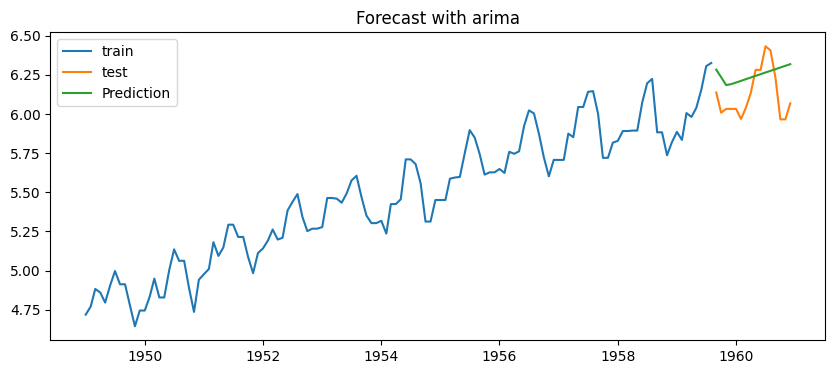

mean absolute error: 0.17
mean absolute percentage error: 3.0%
r2 score: -0.65
root mean squared error: 0.19


,mae,mape,r2,rmse
0,0.17,3.0,-0.65,0.19


In [17]:
model_evaluator(train['#Passengers'].ffill(), test['#Passengers'].ffill(),arima_forecast, 'arima')

# Sarima

In [18]:
sarima= auto_arima(train['#Passengers'].ffill(),
                   seasonal=True,
                   m=12)

In [19]:
sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                       y   No. Observations:                  128
Model:             SARIMAX(0, 1, 1)x(1, 0, [1, 2], 12)   Log Likelihood                 162.048
Date:                                 Wed, 12 Aug 2026   AIC                           -314.096
Time:                                         19:06:38   BIC                           -299.875
Sample:                                     01-01-1949   HQIC                          -308.318
                                          - 08-01-1959                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5316      0.088     -6.063      0.000      -0.703      -0.360
ar.S.L12       0.9800      0.019     51.659      0.000       0.943       1.017
ma.S.L12      -0.7742      0.114     -6.770      0.000      -0.998      -0.550
ma.S.L24       0.1702      0.119      1.432      0.152      -0.063       0.403
sigma2         0.0037      0.000      9.093      0.000       0.003       0.005
===================================================================================
Ljung-Box (L1) (Q):                   0.22   Jarque-Bera (JB):                 9.40
Prob(Q):                              0.64   Prob(JB):                         0.01
Heteroskedasticity (H):               1.82   Skew:                            -0.29
Prob(H) (two-sided):                  0.06   Kurtosis:                         4.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [20]:
sarima_pred= sarima.predict(len(test))

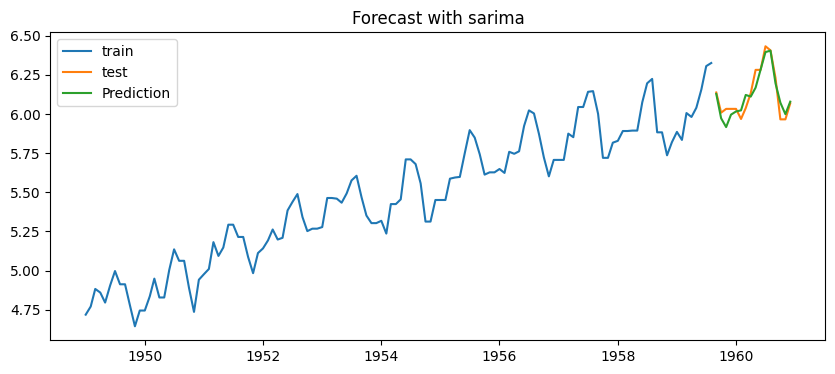

mean absolute error: 0.04
mean absolute percentage error: 1.0%
r2 score: 0.85
root mean squared error: 0.06


,mae,mape,r2,rmse
0,0.04,1.0,0.85,0.06


In [21]:
model_evaluator(train['#Passengers'].ffill(), test['#Passengers'].ffill(),sarima_pred, 'sarima')

# Sarimax

In [22]:
exog_train= train.drop(columns='#Passengers').bfill()
exog_test= test.drop(columns='#Passengers').bfill()

In [23]:
sarimax= auto_arima(train['#Passengers'].ffill(),
                    X= exog_train,
                    m=12,
                    seasonal=True,
                    )

In [24]:
sarimax.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                SARIMAX Results                                 
================================================================================
Dep. Variable:                        y   No. Observations:                  128
Model:             SARIMAX(2, 0, 0, 12)   Log Likelihood                 217.810
Date:                  Wed, 12 Aug 2026   AIC                           -411.620
Time:                          19:08:12   BIC                           -377.396
Sample:                      01-01-1949   HQIC                          -397.715
                           - 08-01-1959                                         
Covariance Type:                    opg                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
month            -0.0076      0.016     -0.482      0.630      -0.038       0.023
quater            0.0357      0.025      1.427      0.154      -0.013       0.085
lag1             -0.6319      0.114     -5.536      0.000      -0.856      -0.408
lag2             -0.7321      0.093     -7.832      0.000      -0.915      -0.549
lag3             -0.1039      0.098     -1.064      0.287      -0.295       0.088
rolling_mean3     2.3221      0.201     11.526      0.000       1.927       2.717
rolling_std3     -0.0185      0.010     -1.915      0.055      -0.037       0.000
rolling_mean6     0.1470      0.158      0.928      0.353      -0.163       0.457
rolling_std6      0.0057      0.014      0.400      0.689      -0.022       0.034
ar.S.L12          0.2814      0.090      3.144      0.002       0.106       0.457
ar.S.L24          0.2636      0.092      2.870      0.004       0.084       0.444
sigma2            0.0019      0.000      6.668      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.24   Jarque-Bera (JB):                22.28
Prob(Q):                              0.63   Prob(JB):                         0.00
Heteroskedasticity (H):               1.01   Skew:                            -0.77
Prob(H) (two-sided):                  0.98   Kurtosis:                         4.34
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [25]:
sarimax_pred= sarimax.predict(len(test), X= exog_test)

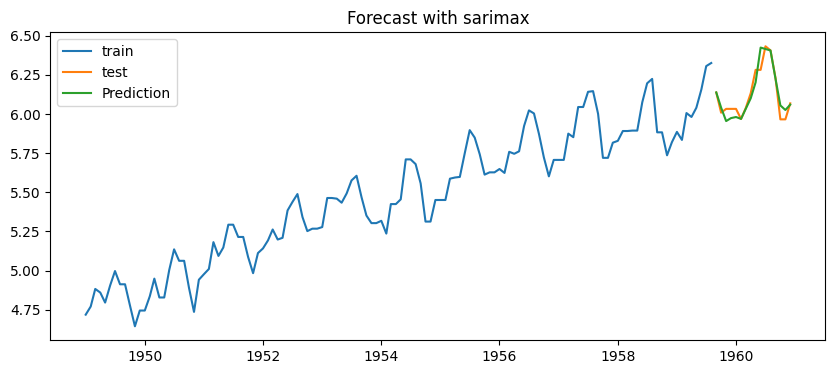

mean absolute error: 0.04
mean absolute percentage error: 1.0%
r2 score: 0.85
root mean squared error: 0.06


,mae,mape,r2,rmse
0,0.04,1.0,0.85,0.06


In [26]:
model_evaluator(train['#Passengers'].ffill(), test['#Passengers'].ffill(),sarimax_pred, 'sarimax')

In [27]:
# Fine tunning 


fine_tuned_model = auto_arima(
    train['#Passengers'].ffill(),
    X=exog_train,
    m=12,
    seasonal=True,
    start_P=0, max_P=3,
    start_q=0, max_Q=3,
    start_p=0, max_p=5,
    start_Q=0, max_q=5,
    maxiter=2000,
    test='kpss',
    seasonal_test='ocsb',
    stepwise=True,
    trace=True,
    information_criterion='aic',
    suppress_warnings=True,
    error_action='ignore'
)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=-402.612, Time=0.37 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=-405.244, Time=3.49 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=-404.110, Time=5.95 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=-404.612, Time=0.64 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=-402.008, Time=1.68 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=-408.606, Time=27.61 sec
 ARIMA(1,0,0)(3,0,0)[12] intercept   : AIC=-410.252, Time=43.11 sec
 ARIMA(1,0,0)(3,0,1)[12] intercept   : AIC=-409.532, Time=138.64 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=-407.356, Time=35.14 sec
 ARIMA(0,0,0)(3,0,0)[12] intercept   : AIC=-411.304, Time=46.17 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AIC=-409.939, Time=13.88 sec
 ARIMA(0,0,0)(3,0,1)[12] intercept   : AIC=-410.349, Time=155.13 sec
 ARIMA(0,0,0)(2,0,1)[12] intercept   : AIC=-411.334, Time=52.97 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=-413.375, Time=33.62 sec
 ARIMA(0

In [28]:
fine_tuned_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 SARIMAX Results                                  
==================================================================================
Dep. Variable:                          y   No. Observations:                  128
Model:             SARIMAX(1, 0, [1], 12)   Log Likelihood                 219.710
Date:                    Wed, 12 Aug 2026   AIC                           -415.419
Time:                            19:27:32   BIC                           -381.195
Sample:                        01-01-1949   HQIC                          -401.514
                             - 08-01-1959                                         
Covariance Type:                      opg                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
month            -0.0173      0.017     -1.033      0.302      -0.050       0.015
quater            0.0489      0.027      1.789      0.074      -0.005       0.102
lag1             -0.6185      0.123     -5.026      0.000      -0.860      -0.377
lag2             -0.6646      0.097     -6.861      0.000      -0.854      -0.475
lag3             -0.1393      0.098     -1.419      0.156      -0.332       0.053
rolling_mean3     2.1894      0.210     10.411      0.000       1.777       2.602
rolling_std3     -0.0184      0.010     -1.881      0.060      -0.038       0.001
rolling_mean6     0.2355      0.162      1.452      0.147      -0.082       0.553
rolling_std6      0.0057      0.014      0.395      0.693      -0.022       0.034
ar.S.L12          0.9529      0.053     18.026      0.000       0.849       1.057
ma.S.L12         -0.7558      0.137     -5.508      0.000      -1.025      -0.487
sigma2            0.0018      0.000      6.908      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.31   Jarque-Bera (JB):                14.47
Prob(Q):                              0.58   Prob(JB):                         0.00
Heteroskedasticity (H):               0.95   Skew:                            -0.67
Prob(H) (two-sided):                  0.87   Kurtosis:                         3.97
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [29]:
fine_tuned_model.get_params

<bound method BaseEstimator.get_params of ARIMA(maxiter=2000, order=(0, 0, 0), scoring_args={},
      seasonal_order=(1, 0, 1, 12), suppress_warnings=True,
      with_intercept=False)>

In [30]:
forecast= fine_tuned_model.predict(n_periods=len(test), X= exog_test)

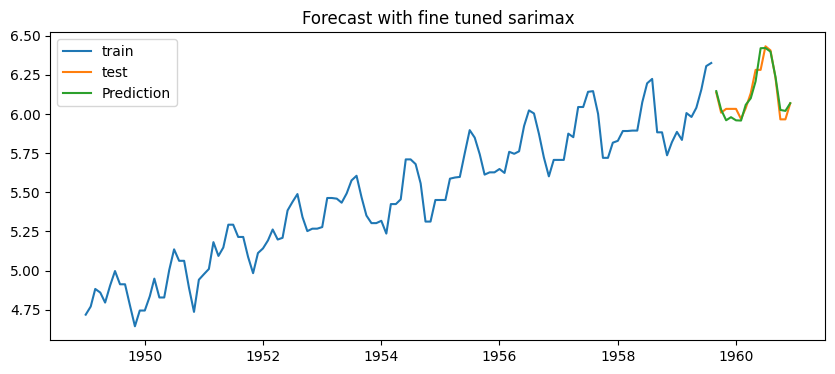

mean absolute error: 0.04
mean absolute percentage error: 1.0%
r2 score: 0.87
root mean squared error: 0.05


In [31]:
sarimax_metric=model_evaluator(train['#Passengers'].ffill(), test['#Passengers'].ffill(),forecast, 'fine tuned sarimax')

In [32]:
sarimax_metric.to_csv('dataset\\sarimax_metric.csv')

In [33]:
df= df.asfreq('MS')
df_exog= df.drop(columns='#Passengers').bfill()

In [34]:
# Future prediction model
# "The final model order was selected based on the lowest AIC obtained during the fine-tuning search."

final_model= ARIMA(order=(0, 0, 0), seasonal_order=(1, 0, 1, 12),maxiter=1000)



In [35]:

final_model.fit(y=df['#Passengers'].ffill(), X=df_exog)

,order,"(0, ...)"
,seasonal_order,"(1, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,1000
,suppress_warnings,False
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,None
,trend,None
,with_intercept,True


In [36]:
final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 SARIMAX Results                                  
==================================================================================
Dep. Variable:                          y   No. Observations:                  144
Model:             SARIMAX(1, 0, [1], 12)   Log Likelihood                 240.392
Date:                    Wed, 12 Aug 2026   AIC                           -454.784
Time:                            19:27:43   BIC                           -416.177
Sample:                        01-01-1949   HQIC                          -439.096
                             - 12-01-1960                                         
Covariance Type:                      opg                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept        -0.0153      0.062     -0.246      0.806      -0.137       0.107
month            -0.0059      0.014     -0.432      0.666      -0.033       0.021
quater            0.0186      0.021      0.904      0.366      -0.022       0.059
lag1             -0.6573      0.110     -6.001      0.000      -0.872      -0.443
lag2             -0.7619      0.093     -8.180      0.000      -0.944      -0.579
lag3             -0.0650      0.093     -0.697      0.486      -0.248       0.118
rolling_mean3     2.4601      0.200     12.326      0.000       2.069       2.851
rolling_std3     -0.0219      0.009     -2.567      0.010      -0.039      -0.005
rolling_mean6     0.0376      0.143      0.264      0.792      -0.242       0.317
rolling_std6     -0.0009      0.019     -0.046      0.963      -0.038       0.037
ar.S.L12          0.3931      0.344      1.142      0.254      -0.282       1.068
ma.S.L12         -0.1347      0.371     -0.363      0.717      -0.863       0.593
sigma2            0.0021      0.000      6.460      0.000       0.001       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.35   Jarque-Bera (JB):                43.13
Prob(Q):                              0.56   Prob(JB):                         0.00
Heteroskedasticity (H):               1.17   Skew:                            -0.92
Prob(H) (two-sided):                  0.59   Kurtosis:                         4.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [37]:
last_date= df.index[-1]
last_date

Timestamp('1960-12-01 00:00:00')

In [38]:
period= 12

future_dates= pd.date_range(
  start=last_date + pd.DateOffset(months=1),
  periods=period ,
  freq='MS'
)

In [39]:
future_dates

DatetimeIndex(['1961-01-01', '1961-02-01', '1961-03-01', '1961-04-01',
               '1961-05-01', '1961-06-01', '1961-07-01', '1961-08-01',
               '1961-09-01', '1961-10-01', '1961-11-01', '1961-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [40]:
future_data= pd.DataFrame(index=future_dates)

In [47]:

def build_exog_row(model, history, future_dates_df, target_col="#Passengers"):
 
    history = history.copy()
    all_exog_rows = []
    all_predictions = []

    for date in future_dates:

        month_number = np.log(date.month)
        quarter_number = np.log(date.quarter)

        lag1  = history.iloc[-1]  if len(history) >= 1  else history.iloc[0]
        lag2  = history.iloc[-2]  if len(history) >= 2  else history.iloc[0]
        lag3  = history.iloc[-3]  if len(history) >= 3  else history.iloc[0]


        last_3_months  = history.iloc[-3:]  if len(history) >= 3  else history
        last_6_months  = history.iloc[-6:]  if len(history) >= 6  else history
        last_12_months = history.iloc[-12:] if len(history) >= 12 else history

        rolling_mean_3  = last_3_months.mean()
        rolling_std_3   = last_3_months.std() if len(last_3_months) > 1 else 0.0

        rolling_mean_6  = last_6_months.mean()
        rolling_std_6   = last_6_months.std() if len(last_6_months) > 1 else 0.0

      

        one_row = pd.DataFrame({
            "month": [month_number],
            "quater": [quarter_number],
            "lag1": [lag1],
            "lag2": [lag2],
            "lag3": [lag3],
            "rolling_mean3": [rolling_mean_3],
            "rolling_std3": [rolling_std_3],
            "rolling_mean6": [rolling_mean_6],
            "rolling_std6": [rolling_std_6],
           
        }, index=[date])

        all_exog_rows.append(one_row)

        prediction = model.predict(n_periods=1, X=one_row)

        if hasattr(prediction, "iloc"):
            predicted_value = float(prediction.iloc[0])
        else:
            predicted_value = float(prediction[0])

        all_predictions.append(predicted_value)

        history.loc[date] = predicted_value

   
    future_exog = pd.concat(all_exog_rows)
    forecast = pd.Series(all_predictions, index=future_dates, name=target_col)

    return future_exog, forecast

In [48]:
history = df["#Passengers"].ffill()  

future_exog, forecast = build_exog_row(final_model, history, future_data)


In [49]:
future_exog.head()

,month,quater,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
1961-01-01,0.000000,0.000000,6.068426,5.966147,5.966147,6.000240,0.059051,6.178503,0.210667
1961-02-01,0.693147,0.000000,6.062130,6.068426,5.966147,6.032234,0.057320,6.116702,0.171925
1961-03-01,1.098612,0.000000,6.060686,6.062130,6.068426,6.063747,0.004115,6.059003,0.096696
1961-04-01,1.386294,0.693147,6.133958,6.060686,6.062130,6.085591,0.041893,6.042916,0.065439
1961-05-01,1.609438,0.693147,6.150831,6.133958,6.060686,6.115158,0.047923,6.073696,0.065542


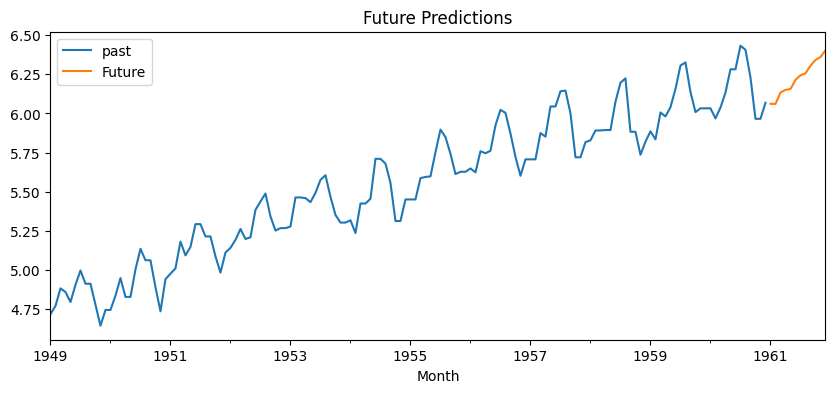

In [50]:
plt.figure(figsize=(10,4))
df['#Passengers'].ffill().plot(label='past')
forecast.plot(label='Future')

plt.legend()
plt.title('Future Predictions')
plt.show()

In [51]:
np.exp(forecast)

1961-01-01    429.288976
1961-02-01    428.669305
1961-03-01    461.258370
1961-04-01    469.107132
1961-05-01    471.748885
1961-06-01    499.986885
1961-07-01    514.978305
1961-08-01    521.490534
1961-09-01    547.514026
1961-10-01    567.878557
1961-11-01    578.574564
1961-12-01    604.005810
Freq: MS, Name: #Passengers, dtype: float64

In [46]:
joblib.dump(final_model, r"models\sarimax.pkl")

['models\\sarimax.pkl']